# How to use Google Colab
#  

### MNIST, Convolutional Neural Network (CNN)

### Step - 3

### MNIST由手寫阿拉伯數字組成，包含60,000個訓練樣本和10,000個測試樣本。

##### data from: https://keras.io/datasets/#mnist-database-of-handwritten-digits
##### code modified from: TensorFlow+Keras[深度學習]人工智慧實務應用 / 林大貴


# (1) Import the data from Keras

In [1]:
from keras.utils import np_utils
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
np.random.seed(3)

Using TensorFlow backend.


In [5]:
# (x_train_image, y_train_label), (x_test_image, y_test_label) = mnist.load_data()

# upload a file to Google CoLab
from google.colab import files
uploaded = files.upload() # then browse, select the files. It's then uploaded

Saving mnist.npz to mnist.npz


In [6]:
# present working directory
!pwd

/content


In [7]:
# list files in the directory
!ls -l

total 11228
-rw-r--r-- 1 root root 11490434 Nov 12 14:09 mnist.npz
drwxr-xr-x 2 root root     4096 Nov  7 20:08 sample_data


In [0]:
%mkdir dataset

In [9]:
!ls -l

total 11232
drwxr-xr-x 2 root root     4096 Nov 12 14:10 dataset
-rw-r--r-- 1 root root 11490434 Nov 12 14:09 mnist.npz
drwxr-xr-x 2 root root     4096 Nov  7 20:08 sample_data


In [0]:
# copy a file to a directory
!cp mnist.npz dataset

In [14]:
# list files in CoLab
!ls -l dataset

total 11224
-rw-r--r-- 1 root root 11490434 Nov 12 14:12 mnist.npz


In [0]:
# !rm *.*

In [16]:
# read in the file
from numpy import load 

data = load('sample_data/mnist.npz')
lst = data.files
print(lst)

['x_test', 'x_train', 'y_train', 'y_test']


In [18]:
x_test_image  = data['x_test']     
x_train_image = data['x_train']
y_test_label  = data['y_test']
y_train_label = data['y_train']

print(x_train_image.shape)
print(y_train_label.shape)
print(x_test_image.shape)
print(y_test_label.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


# (2) View the first 10 images and labels

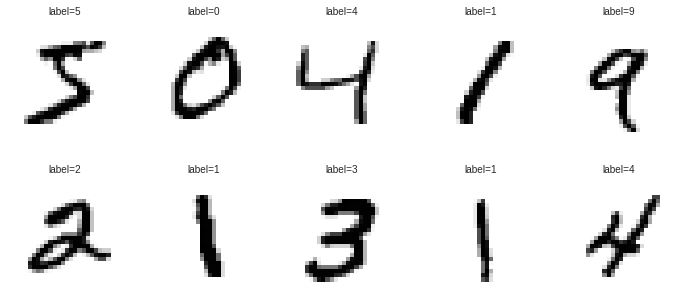

In [19]:
fig = plt.gcf()
fig.set_size_inches(12,14)

for i in range(0,10):
    ax=plt.subplot(5,5,1+i)
    ax.imshow(x_train_image[i], cmap='binary')
    title= "label=" +str(y_train_label[i])
    ax.set_title(title,fontsize=10) 
    ax.set_xticks([]);ax.set_yticks([])        
plt.show()

# (3) Convert 2-D image to nx28x28x1 array, normalize the numbers

In [0]:
# convert 2-D 28x28 image to 4-D nx28x28x1  array

x_Train4D=x_train_image.reshape(x_train_image.shape[0],28,28,1).astype('float32')
x_Test4D=x_test_image.reshape(x_test_image.shape[0],28,28,1).astype('float32')

In [21]:
# normalize the image numbers to 0~1

x_Train4D_normalize = x_Train4D / 255
x_Test4D_normalize = x_Test4D / 255
print(x_Train4D_normalize.shape)
print(x_Test4D_normalize.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# (4) Convert label number to one-hot encoding

In [22]:
# convert label numbers to one-hot encoding

y_TrainOneHot = np_utils.to_categorical(y_train_label)
y_TestOneHot = np_utils.to_categorical(y_test_label)
print(y_TrainOneHot.shape)
print(y_TestOneHot.shape)

(60000, 10)
(10000, 10)


# (5) Use a Convolutional Neural Network

In [0]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D

In [0]:
model = Sequential()

In [0]:
model.add(Conv2D(filters=16,
                 kernel_size=(5,5),
                 padding='same',
                 input_shape=(28,28,1), 
                 activation='relu'))

In [0]:
# Enable this cell in the second step

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=36,
                 kernel_size=(5,5),
                 padding='same',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

In [0]:
model.add(Flatten())

In [0]:
# Enable this cell in the second step

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

In [0]:
model.add(Dense(10,activation='softmax'))

In [30]:
print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 28, 28, 16)        416       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 16)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 14, 14, 36)        14436     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 7, 7, 36)          0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 7, 7, 36)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 1764)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               225920    
__________

# (6) Model training

In [0]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',metrics=['accuracy']) 

In [32]:
train_history=model.fit(x=x_Train4D_normalize, 
                        y=y_TrainOneHot,validation_split=0.2, 
                        epochs=50, batch_size=300,verbose=2)

Train on 48000 samples, validate on 12000 samples
Epoch 1/50
 - 7s - loss: 0.4863 - acc: 0.8463 - val_loss: 0.1008 - val_acc: 0.9699
Epoch 2/50
 - 3s - loss: 0.1419 - acc: 0.9577 - val_loss: 0.0653 - val_acc: 0.9794
Epoch 3/50
 - 3s - loss: 0.1022 - acc: 0.9694 - val_loss: 0.0557 - val_acc: 0.9838
Epoch 4/50
 - 3s - loss: 0.0865 - acc: 0.9740 - val_loss: 0.0480 - val_acc: 0.9850
Epoch 5/50
 - 3s - loss: 0.0725 - acc: 0.9781 - val_loss: 0.0429 - val_acc: 0.9878
Epoch 6/50
 - 3s - loss: 0.0618 - acc: 0.9815 - val_loss: 0.0399 - val_acc: 0.9884
Epoch 7/50
 - 3s - loss: 0.0554 - acc: 0.9833 - val_loss: 0.0391 - val_acc: 0.9886
Epoch 8/50
 - 3s - loss: 0.0494 - acc: 0.9848 - val_loss: 0.0352 - val_acc: 0.9894
Epoch 9/50
 - 3s - loss: 0.0468 - acc: 0.9850 - val_loss: 0.0360 - val_acc: 0.9898
Epoch 10/50
 - 3s - loss: 0.0416 - acc: 0.9870 - val_loss: 0.0357 - val_acc: 0.9896
Epoch 11/50
 - 3s - loss: 0.0369 - acc: 0.9887 - val_loss: 0.0332 - val_acc: 0.9900
Epoch 12/50
 - 3s - loss: 0.0363 - 

# (7) Training history

In [0]:
def show_train_history(train_history,train,validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

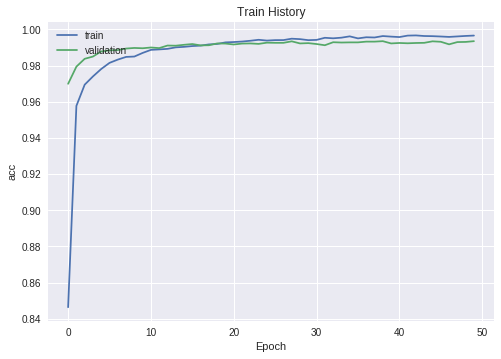

In [34]:
show_train_history(train_history,'acc','val_acc')

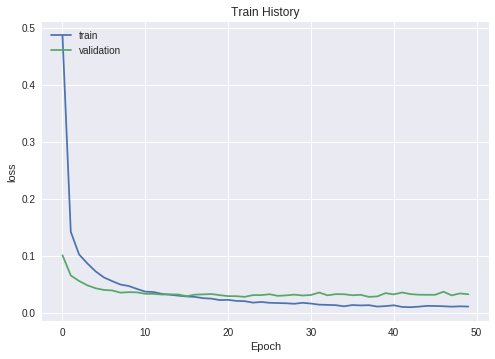

In [35]:
show_train_history(train_history,'loss','val_loss')

# (8) Accuracy

In [36]:
scores = model.evaluate(x_Test4D_normalize, y_TestOneHot)
print()
print('accuracy=',scores[1])

10000/10000 [==============================] - 1s 97us/step

accuracy= 0.9943


# (9) Prediction

In [0]:
prediction=model.predict_classes(x_Test4D_normalize)

In [0]:
def plot_images_labels_prediction(images,labels,prediction,
                                  idx,num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num>25: num=25 
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images[idx], cmap='binary')
        title= "label=" +str(labels[idx])
        if len(prediction)>0:
            title+=",predict="+str(prediction[idx]) 
            
        ax.set_title(title,fontsize=10) 
        ax.set_xticks([]);ax.set_yticks([])        
        idx+=1 
    plt.show()

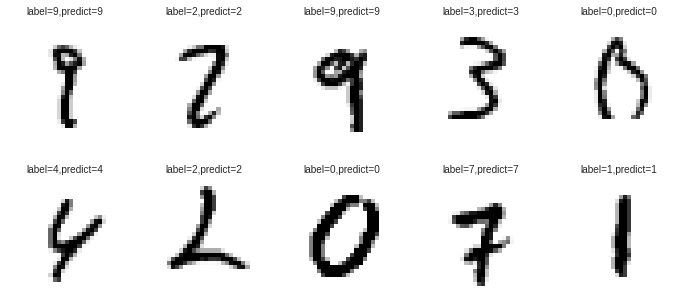

In [39]:
plot_images_labels_prediction(x_test_image,y_test_label,
                              prediction,idx=320)

# (10) Confusion matrix

In [40]:
pd.crosstab(y_test_label,prediction,
            rownames=['label'],colnames=['predict'])

predict,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
0,978,0,0,0,0,0,0,1,1,0
1,0,1134,1,0,0,0,0,0,0,0
2,0,1,1030,0,0,0,0,1,0,0
3,0,0,0,1007,0,2,0,0,1,0
4,0,0,0,0,975,0,1,0,1,5
5,1,0,0,5,0,885,1,0,0,0
6,3,1,0,0,1,3,949,0,1,0
7,0,2,3,0,0,0,0,1021,1,1
8,2,0,4,1,0,0,1,0,965,1
